In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [2]:
# Read Dataset
df=pd.read_json('val_data.json',lines=True)
df.head()

,image_url,image_path,brand,product_title,class_label,color
0,https://m.media-amazon.com/images/I/81LOPbFPiQ...,images/val/0.jpeg,Generic,Women's Khadi Cotton Saree With Blouse Piece (...,saree,NaN
1,https://m.media-amazon.com/images/I/81Q8Oktw4s...,images/val/1.jpeg,Yashvi Designer,Women's Net Saree With Unstitched Blouse Piece,saree,NaN
2,https://m.media-amazon.com/images/I/613S1YGCmo...,images/val/2.jpeg,Aarrah,Georgette Strip Print Saree[S_SHIKHA30021SR02_...,saree,NaN
3,https://m.media-amazon.com/images/I/819budhQl1...,images/val/3.jpeg,MIMOSA,Women's Patola Style Art Silk Saree (Green),saree,NaN
4,https://m.media-amazon.com/images/I/61cAZ94ZQV...,images/val/4.jpeg,Generic,Women's Pure Hand Block Patola Printed Cotton ...,saree,NaN


In [3]:
df.shape

(7500, 6)

In [4]:
#Class Distribution
df['class_label'].value_counts()

class_label
saree                   500
blouse                  500
dhoti_pants             500
dupattas                500
gowns                   500
kurta_men               500
leggings_and_salwars    500
lehenga                 500
mojaris_men             500
mojaris_women           500
nehru_jackets           500
palazzos                500
petticoats              500
sherwanis               500
women_kurta             500
Name: count, dtype: int64

In [5]:
#keeping required cloumn only
df = df[['image_path', 'class_label']]
df.head()


,image_path,class_label
0,images/val/0.jpeg,saree
1,images/val/1.jpeg,saree
2,images/val/2.jpeg,saree
3,images/val/3.jpeg,saree
4,images/val/4.jpeg,saree


In [6]:
#checking for any null or nan values
print('Null Values:\n',df.isnull().sum())
print('NaN Values:\n',df.isna().sum())

Null Values:
 image_path     0
class_label    0
dtype: int64
NaN Values:
 image_path     0
class_label    0
dtype: int64


In [7]:
#converting the categorical value into numberic label
le=LabelEncoder()
df['class_label']=le.fit_transform(df['class_label'])
dict(zip(le.classes_, le.transform(le.classes_)))

{'blouse': np.int64(0),
 'dhoti_pants': np.int64(1),
 'dupattas': np.int64(2),
 'gowns': np.int64(3),
 'kurta_men': np.int64(4),
 'leggings_and_salwars': np.int64(5),
 'lehenga': np.int64(6),
 'mojaris_men': np.int64(7),
 'mojaris_women': np.int64(8),
 'nehru_jackets': np.int64(9),
 'palazzos': np.int64(10),
 'petticoats': np.int64(11),
 'saree': np.int64(12),
 'sherwanis': np.int64(13),
 'women_kurta': np.int64(14)}

In [8]:
#making a train test split ensuring equal proportion of subclass in both the dataset
train_df, test_df = train_test_split(
    df, test_size=0.3, stratify=df["class_label"], random_state=42
)


In [9]:
print('Train Dataset Shape:',train_df.shape)
print('Test Dataset Shape:',test_df.shape)


Train Dataset Shape: (5250, 2)
Test Dataset Shape: (2250, 2)


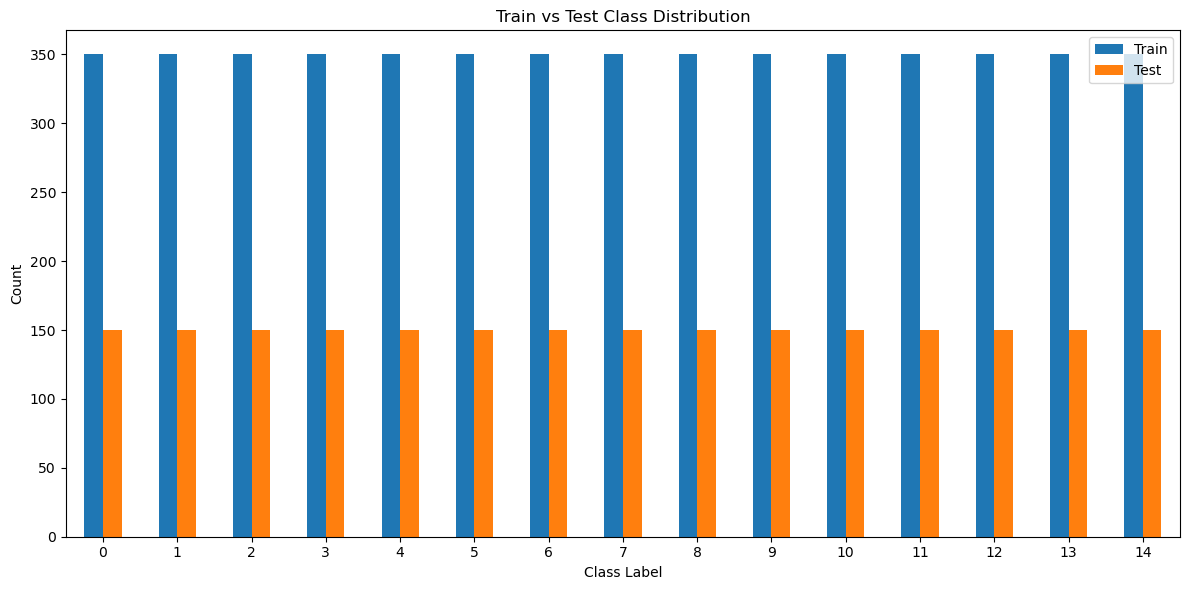

In [10]:
train_counts = train_df['class_label'].value_counts().sort_index()
test_counts = test_df['class_label'].value_counts().sort_index()

df_plot = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})

df_plot.plot(kind='bar', figsize=(12,6))

plt.title('Train vs Test Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
#creating class for data loader that will take the image from the path and make it ML ready
class ImageDataLoader:
    def __init__(self, df, img_size=(128, 256), batch_size=32, shuffle=True):
        self.df = df
        self.img_size = img_size
        self.batch_size = batch_size
        self.shuffle = shuffle

    #below function will store the image_path and label pair 
    def _df_to_dataset(self):
        paths = self.df["image_path"].values
        labels = self.df["class_label"].values
        return tf.data.Dataset.from_tensor_slices((paths, labels))

    #this function will read image and resize it and return image label pair
    def _load_image(self, path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        
        img = tf.image.resize(img, self.img_size)
        img = img / 255.0
        
        return img, label

    #below function will run only if augment is set True this will twick the image diffrent ways 
    def _augment(self, img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        return img, label

    #this function will return the dataset in batches for train and test
    def get_dataset(self, augment=False):
        ds = self._df_to_dataset()
        
        ds = ds.map(self._load_image, num_parallel_calls=tf.data.AUTOTUNE)
        
        if self.shuffle:
            ds = ds.shuffle(buffer_size=1000)
        
        if augment:
            ds = ds.map(self._augment, num_parallel_calls=tf.data.AUTOTUNE)
        
        ds = ds.batch(self.batch_size)
        ds = ds.prefetch(tf.data.AUTOTUNE)
        
        return ds

In [12]:
train_dataset = ImageDataLoader(train_df)
test_dataset = ImageDataLoader(test_df, shuffle=False)

train_ds = train_dataset.get_dataset(augment=True)
test_ds = test_dataset.get_dataset()

In [13]:
print("Training Dataset Size:")
print("Samples:", len(train_df))
print("Batch size:", train_dataset.batch_size)
print("Batches:", len(train_ds))

print("\nTraining Dataset Size:")
print("Samples:", len(test_df))
print("Batch size:", test_dataset.batch_size)
print("Batches:", len(test_ds))

Training Dataset Size:
Samples: 5250
Batch size: 32
Batches: 165

Training Dataset Size:
Samples: 2250
Batch size: 32
Batches: 71


# Model Training: MobileNetV2

In [14]:
num_classes = len(df['class_label'].unique())

# Load MobileNetV2 without top layers
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 256, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model weights
base_model.trainable = False


C:\Users\prath\AppData\Local\Temp\ipykernel_21368\2461257934.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [15]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # because labels are integers
    metrics=['accuracy'])

In [17]:
history = model.fit(
    train_ds,
    epochs=15,
    verbose=1
)

Epoch 1/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 28s 151ms/step - accuracy: 0.5352 - loss: 1.4543
Epoch 2/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 26s 158ms/step - accuracy: 0.6800 - loss: 0.9526
Epoch 3/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 25s 148ms/step - accuracy: 0.7278 - loss: 0.7936
Epoch 4/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step - accuracy: 0.7547 - loss: 0.7121
Epoch 5/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step - accuracy: 0.7528 - loss: 0.6959
Epoch 6/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step - accuracy: 0.7844 - loss: 0.6185
Epoch 7/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step - accuracy: 0.8029 - loss: 0.5733
Epoch 8/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 26s 156ms/step - accuracy: 0.8091 - loss: 0.5316
Epoch 9/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 26s 154ms/step - accuracy: 0.8242 - loss: 0.4923
Epoch 10/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 27s 161ms/step - accuracy: 0.8206 - loss: 0.5081
Epoch 11/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 26s 156ms/step - accuracy: 0.8427 - loss: 0.4452
Epoch 12/15
165/165

In [18]:
# Unfreeze last 50 layers
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_fine = model.fit(
    train_ds,
    epochs=10,
    verbose=1
)

Epoch 1/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 54s 275ms/step - accuracy: 0.6190 - loss: 1.2192
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 48s 290ms/step - accuracy: 0.7130 - loss: 0.8453
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 48s 287ms/step - accuracy: 0.7564 - loss: 0.7085
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 49s 296ms/step - accuracy: 0.7669 - loss: 0.6455
Epoch 5/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 47s 283ms/step - accuracy: 0.8053 - loss: 0.5750
Epoch 6/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 49s 293ms/step - accuracy: 0.8166 - loss: 0.5320
Epoch 7/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 48s 286ms/step - accuracy: 0.8276 - loss: 0.4921
Epoch 8/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 48s 288ms/step - accuracy: 0.8328 - loss: 0.4637
Epoch 9/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 47s 285ms/step - accuracy: 0.8581 - loss: 0.4258
Epoch 10/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 48s 287ms/step - accuracy: 0.8594 - loss: 0.3992


In [19]:
#Evaluating model performance on test dataset
loss, accuracy = model.evaluate(test_ds)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step - accuracy: 0.7836 - loss: 0.7533
Test Loss: 0.7533495426177979
Test Accuracy: 0.7835555672645569


In [20]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds_classes = np.argmax(preds, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [21]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       150
           1       0.77      0.63      0.69       150
           2       0.81      0.58      0.68       150
           3       0.58      0.63      0.60       150
           4       0.74      0.89      0.81       150
           5       0.74      0.73      0.73       150
           6       0.93      0.83      0.87       150
           7       0.87      0.83      0.85       150
           8       0.82      0.86      0.84       150
           9       0.92      0.82      0.87       150
          10       0.85      0.81      0.83       150
          11       0.79      0.87      0.83       150
          12       0.73      0.87      0.80       150
          13       0.86      0.83      0.85       150
          14       0.56      0.63      0.59       150

    accuracy                           0.78      2250
   macro avg       0.79      0.78      0.78      2250
weighted avg       0.79   

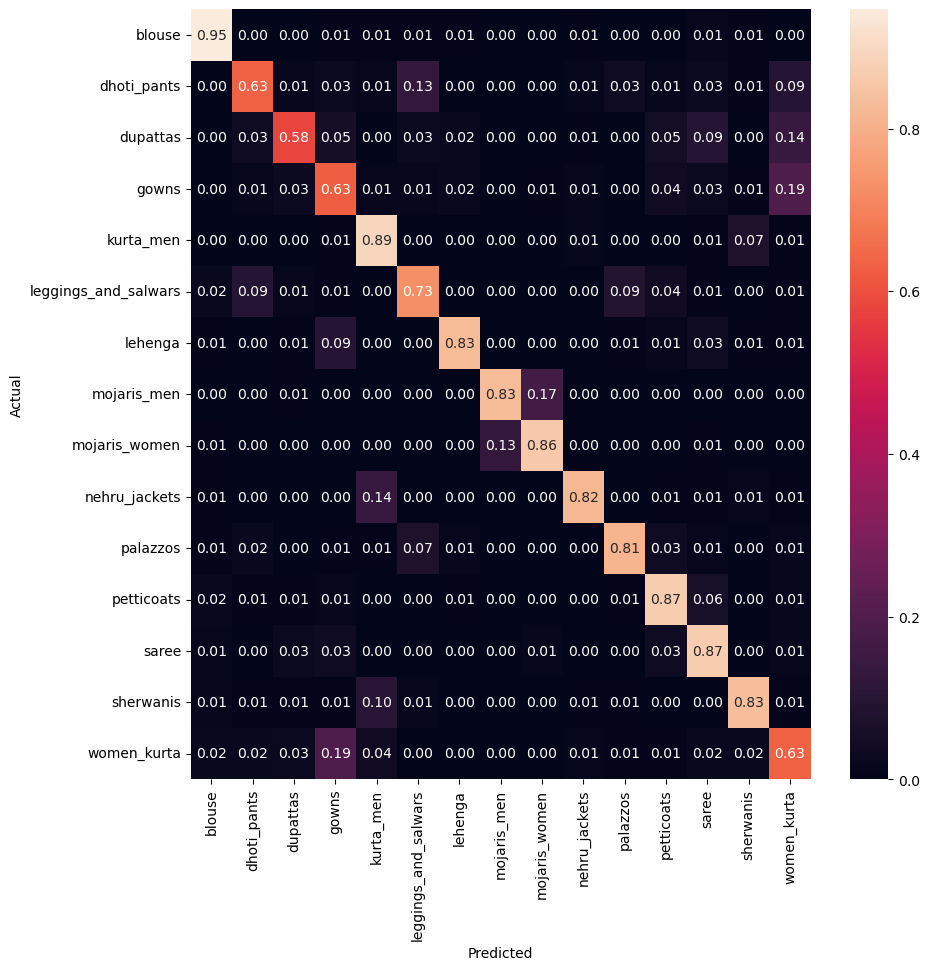

In [22]:
cm = confusion_matrix(y_true, y_pred)
# Normalise
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show(block=False)